
# Erasmus+ KA1 Mobility: Hidden Patterns Behind Who Moves Where

**Master's-level exploratory, clustering and machine-learning analysis**

This notebook goes beyond descriptive "which country sends the most students" statistics.
The guiding research question is:

> *Can we recover latent, non-obvious mobility **archetypes** — combining economic context
> (Harmonised Index of Consumer Prices, HICP), academic prestige (university rankings) and
> student-level attributes — that are not visible from any single variable in isolation?*

**Data sources**

| File | Role |
|---|---|
| `df_mobility_hicp.csv` | Primary KA1 mobility dataset, enriched with sending/receiving country HICP (cost-of-living / inflation proxy) |
| `university_rankings_europe_2014_2024.csv` | CWUR-style European university rankings, 2014–2024 |
| `mapping_uni.json` | Canonical-name → spelling-variant dictionary, used for entity resolution of institution names across the mobility dataset |
| `dataframe_1000_examples.csv` | Same population as `df_mobility_hicp.csv` without the HICP columns — used only as a cross-check that the HICP file is a superset |

**Analytical roadmap**

1. Data auditing & cleaning (the dataset is *intentionally* dirty — inconsistent codes, duplicated ISCED labels, `Türkiye`/`Turkey` split, censored ranking values)
2. Rankings cleaning & parsing of censored values (`"355+"`, `"> 1000"`, `"-"`)
3. **Entity resolution**: fuzzy-matching mobility organisations to ranked institutions to derive an *academic-prestige gap* feature
4. Feature engineering (economic gap, prestige gap, temporal features)
5. Exploratory data analysis
6. **Unsupervised learning**: standardisation → Elbow method → Silhouette analysis → K-Means → PCA projection & biplot → Hierarchical clustering (validation) → cluster profiling
7. A second, independent clustering at **country level** (mobility archetypes: hubs / net senders / reciprocal)
8. **Supervised learning**: Random Forest classifier to uncover the drivers of the *"Fewer Opportunities"* disadvantage flag, with permutation-validated feature importance
9. Synthesis of findings


In [1]:

import json
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              RocCurveDisplay, balanced_accuracy_score)
from sklearn.inspection import permutation_importance

from rapidfuzz import fuzz, process

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
RNG = 42


## 1. Loading & first audit

In [2]:

mob = pd.read_csv("df_mobility_hicp.csv", index_col=0)
mob_noHICP = pd.read_csv("dataframe_1000_examples.csv", index_col=0)
rank_raw = pd.read_csv("university_rankings_europe_2014_2024.csv")
with open("mapping_uni.json", encoding="utf-8") as f:
    name_mapping = json.load(f)

print("KA1 mobility (with HICP):", mob.shape)
print("KA1 mobility (no HICP)  :", mob_noHICP.shape)
print("University rankings     :", rank_raw.shape)
print("Name-mapping entries    :", len(name_mapping))
mob.head(3)


KA1 mobility (with HICP): (1000, 16)
KA1 mobility (no HICP)  : (1000, 14)
University rankings     : (4231, 9)
Name-mapping entries    : 72


,Academic Year,Mobility Duration,Field of Education,Participant Country,Education Level,Participant Gender,Fewer Opportunities,Participant Age,Sending Country,Sending Country HICP,Sending City,Sending Organization,Receiving Country,Receiving Country HICP,Receiving City,Receiving Organization
0,2016,121,Arts,France,ISCED-7 - Second cycle / Master’s or equivalen...,Male,Yes,25,France,100.31,METZ,Ecole Supérieure d'Art de Lorraine,Turkey,107.66,ISTANBUL,Sabanci University
1,2019,42,Chemistry,Belgium,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,No,21,Belgium,107.77,Geel,THOMAS MORE KEMPEN VZW,Poland,104.80,Gdansk,UNIWERSYTET GDANSKI
2,2017,139,Business and administration,France,ISCED-7 - Second cycle / Master’s or equivalen...,Male,No,24,France,101.47,BELFORT,ASSOCIATION POUR LA GESTION DE L'ECOLE SUPERIE...,Germany,102.10,BIETIGHEIM-BISSINGEN,MAGNA CAR TOP SYSTEMS GmbH


In [3]:

# Sanity check: is df_mobility_hicp.csv really the same population as dataframe_1000_examples.csv,
# just enriched with two HICP columns? (as stated in the prompt)
common_cols = [c for c in mob_noHICP.columns if c in mob.columns]
same_population = (mob[common_cols].reset_index(drop=True)
                    .equals(mob_noHICP[common_cols].reset_index(drop=True)))
print("Identical population on shared columns:", same_population)
print("\nMissing-value audit (df_mobility_hicp):")
print(mob.isna().sum())


Identical population on shared columns: True

Missing-value audit (df_mobility_hicp):
Academic Year              0
Mobility Duration          0
Field of Education         0
Participant Country        0
Education Level            0
Participant Gender         0
Fewer Opportunities        0
Participant Age            0
Sending Country            0
Sending Country HICP      21
Sending City               0
Sending Organization       0
Receiving Country          0
Receiving Country HICP    21
Receiving City             0
Receiving Organization     0
dtype: int64



Confirmed: `df_mobility_hicp.csv` is the analytical dataset of record (same 1000 mobilities,
plus `Sending/Receiving Country HICP`). We drop `dataframe_1000_examples.csv` from further use,
as instructed, and work exclusively with `mob`.


## 2. Data cleaning — the dataset is deliberately messy

In [4]:

for c in ["Fewer Opportunities", "Education Level", "Participant Gender", "Participant Country"]:
    print(f"--- {c} ---")
    print(mob[c].value_counts(dropna=False))
    print()


--- Fewer Opportunities ---
Fewer Opportunities
No     556
0      274
1       65
-       56
Yes     41
???      8
Name: count, dtype: int64

--- Education Level ---
Education Level
ISCED-6 - First cycle / Bachelor’s or equivalent level (EQF-6)                           632
ISCED-7 - Second cycle / Master’s or equivalent level (EQF-7)                            312
ISCED-5 - Short-cycle within the first cycle / Short-cycle tertiary education (EQF-5)     25
ISCED-8 - Third cycle / Doctoral or equivalent level (EQF-8)                              13
ISCED-5 - Short cycle within the first cycle / Short-cycle tertiary education (EQF-5)     10
ISCED-9 - Not elsewhere classified                                                         8
Name: count, dtype: int64

--- Participant Gender ---
Participant Gender
Female    623
Male      377
Name: count, dtype: int64

--- Participant Country ---
Participant Country
Germany        146
France         128
Italy          121
Spain          119
Poland   


Three concrete data-quality issues surface immediately and would silently corrupt any
downstream clustering or ML step if left untouched:

1. **`Fewer Opportunities`** is encoded with *six* inconsistent labels (`No`, `0`, `Yes`, `1`,
   `-`, `???`) instead of a clean boolean — a classic multi-source ETL artefact.
2. **`Education Level`** contains a duplicated ISCED-5 category (`"Short-cycle"` vs.
   `"Short cycle"` — a single missing hyphen creates a phantom category).
3. **`Participant Age = -1`** is a sentinel/placeholder for a missing value, not a real age.

We also anticipate (from the earlier audit) that `Sending/Receiving Country` mixes
**`Turkey`** and **`Türkiye`** as if they were different countries — this matters a lot,
because Turkey's HICP series is the only hyperinflation-scale series in the data
(base ≈100 → 900+), so splitting it in two silently biases any country-level aggregation.


In [5]:

mob_clean = mob.copy()

# --- 1. Fewer Opportunities -> clean boolean + explicit "Unknown" category ---
fo_map = {"Yes": True, "1": True, 1: True,
          "No": False, "0": False, 0: False}
mob_clean["Fewer Opportunities Clean"] = mob_clean["Fewer Opportunities"].map(fo_map)
# "-" and "???" become explicit missing (kept as a category, not silently dropped)
n_unknown_fo = mob_clean["Fewer Opportunities Clean"].isna().sum()
print(f"'Fewer Opportunities' -> {n_unknown_fo} rows recoded as Unknown "
      f"({n_unknown_fo/len(mob_clean):.1%} of the sample)")

# --- 2. Education level: merge the hyphen-typo duplicate ---
mob_clean["Education Level"] = (mob_clean["Education Level"]
                                 .str.replace("Short cycle", "Short-cycle", regex=False))
mob_clean["ISCED Level"] = mob_clean["Education Level"].str.extract(r"ISCED-(\d)").astype(int)

# --- 3. Age sentinel -> NaN ---
mob_clean.loc[mob_clean["Participant Age"] < 0, "Participant Age"] = np.nan
print(f"Age sentinels (-1) recoded to NaN: {mob['Participant Age'].lt(0).sum()}")

# --- 4. Country harmonisation: Türkiye == Turkey ---
def harmonise_country(s):
    return s.replace({"Türkiye": "Turkey"})

for col in ["Participant Country", "Sending Country", "Receiving Country"]:
    mob_clean[col] = harmonise_country(mob_clean[col])

print("\nEducation Level categories after cleaning:", mob_clean["Education Level"].nunique())
print("Distinct Sending Country values after harmonisation:", mob_clean["Sending Country"].nunique(),
      "(was", mob["Sending Country"].nunique(), ")")


'Fewer Opportunities' -> 64 rows recoded as Unknown (6.4% of the sample)
Age sentinels (-1) recoded to NaN: 1

Education Level categories after cleaning: 5
Distinct Sending Country values after harmonisation: 38 (was 39 )


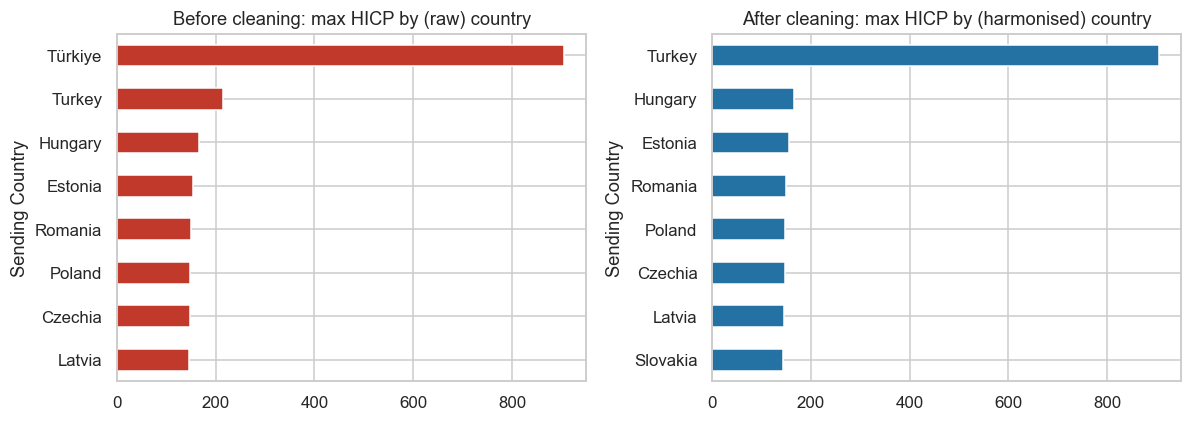

In [6]:

# Effect of the Türkiye/Turkey merge on the HICP outlier picture
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mob.groupby("Sending Country")["Sending Country HICP"].max().sort_values(ascending=False).head(8)\
   .plot(kind="barh", ax=axes[0], color="#c0392b")
axes[0].set_title("Before cleaning: max HICP by (raw) country")
axes[0].invert_yaxis()

mob_clean.groupby("Sending Country")["Sending Country HICP"].max().sort_values(ascending=False).head(8)\
   .plot(kind="barh", ax=axes[1], color="#2471a3")
axes[1].set_title("After cleaning: max HICP by (harmonised) country")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()



Turkey's HICP genuinely reaches ~900 (base ≈100) by 2024 — this is **not** a data error but a
reflection of real, severe Turkish-lira inflation over the period; however, before harmonisation
it looked like two unrelated countries with wildly different inflation profiles. This is exactly
the kind of silent bias that would have distorted a "sending-country" cluster centroid.


In [7]:

# HICP missingness: 21 rows on each side. We impute with the country-year median
# (falls back to country median, then global median) rather than dropping rows.
def impute_hicp(df, country_col, hicp_col):
    df = df.copy()
    country_median = df.groupby(country_col)[hicp_col].transform("median")
    df[hicp_col] = df[hicp_col].fillna(country_median)
    df[hicp_col] = df[hicp_col].fillna(df[hicp_col].median())
    return df[hicp_col]

mob_clean["Sending Country HICP"] = impute_hicp(mob_clean, "Sending Country", "Sending Country HICP")
mob_clean["Receiving Country HICP"] = impute_hicp(mob_clean, "Receiving Country", "Receiving Country HICP")

# Age: impute remaining NaNs with the (Education Level)-specific median age
mob_clean["Participant Age"] = mob_clean.groupby("ISCED Level")["Participant Age"]\
                                          .transform(lambda s: s.fillna(s.median()))

print("Remaining NaNs after imputation:")
print(mob_clean[["Sending Country HICP", "Receiving Country HICP", "Participant Age"]].isna().sum())


Remaining NaNs after imputation:
Sending Country HICP      0
Receiving Country HICP    0
Participant Age           0
dtype: int64


## 3. Cleaning the university rankings

In [8]:

rank_raw[["Education Rank", "Employability Rank", "Faculty Rank"]].apply(lambda c: c.unique()[:6])


,Education Rank,Employability Rank,Faculty Rank
0,2,10,5
1,7,12,10
2,16,105,13
3,20,406,52
4,8,478+,59
5,150,6,208



The three sub-ranks are **censored** fields, typical of ranking publishers that don't disclose
exact positions beyond a threshold: `"355+"` (worse than 355th, exact rank unknown),
`"> 1000"` (off the scale) and `"-"` (not ranked on that dimension). We parse the numeric floor
of the censored value and keep a boolean flag marking that the true value is right-censored —
turning three "dirty string" columns into usable numeric features without fabricating precision.


In [9]:

def parse_censored_rank(series):
    numeric = pd.to_numeric(series, errors="coerce")               # plain integers
    censored = series.str.extract(r"(\d+)\s*\+")[0]                 # "355+"
    gt1000 = series.str.contains(r">\s*1000", na=False)
    out = numeric.copy()
    out = out.fillna(pd.to_numeric(censored, errors="coerce"))
    out[gt1000] = 1000
    is_censored = series.str.contains(r"\+|>", na=False)
    return out, is_censored

rank = rank_raw.copy()
for col in ["Education Rank", "Employability Rank", "Faculty Rank"]:
    parsed, censored_flag = parse_censored_rank(rank[col])
    rank[col] = parsed
    rank[col + " Censored"] = censored_flag

rank = rank.rename(columns={"Location": "Country"})
print(rank.isna().sum())
rank.describe(include="all").T.head(10)


World Rank                        0
Institution                       0
Country                           0
National Rank                     0
Education Rank                 1549
Employability Rank              858
Faculty Rank                   1846
Score                             0
Year                              0
Education Rank Censored           0
Employability Rank Censored       0
Faculty Rank Censored             0
dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
World Rank,4231.0,NaN,NaN,NaN,481.801938,272.16019,4.0,245.0,469.0,709.0,1000.0
Institution,4231,558,University of Cyprus,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,4231,31,United Kingdom,698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
National Rank,4231.0,NaN,NaN,NaN,18.702671,16.466313,1.0,5.0,12.0,31.0,65.0
Education Rank,2682.0,NaN,NaN,NaN,296.12528,135.724266,1.0,187.25,355.0,378.0,666.0
Employability Rank,3373.0,NaN,NaN,NaN,609.429291,361.449305,2.0,379.0,567.0,820.0,1710.0
Faculty Rank,2385.0,NaN,NaN,NaN,184.313627,66.15049,4.0,142.0,210.0,235.0,303.0
Score,4231.0,NaN,NaN,NaN,64.496422,14.915879,42.49,45.62,71.9,75.8,97.64
Year,4231.0,NaN,NaN,NaN,2018.92295,3.150777,2014.0,2016.0,2019.0,2022.0,2024.0
Education Rank Censored,4231,2,False,3293,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Entity resolution: linking mobility organisations to ranked institutions

This is the step that unlocks the most interesting hidden pattern in the brief: **is Erasmus
mobility systematically directed towards higher-ranked institutions, and does that "prestige gap"
line up with the economic ("HICP gap") incentive, or does it pull in the opposite direction?**

Institution names are free text, entered independently by hundreds of sending/receiving
organisations, so the same university appears under many spellings (`"Universite Paris 1
Pantheon-Sorbonne"` vs `"Université Paris 1 Panthéon-Sorbonne"`). We combine:

1. `mapping_uni.json` — a curated canonical-name → variant-spellings dictionary for the
   **mobility** dataset (verified against `Sending/Receiving Organization`, not the rankings —
   the rankings use yet another naming convention, e.g. `"Toulouse 1 Capitole University"`).
2. Text normalisation (case-fold, strip diacritics/punctuation).
3. Fuzzy token-sort matching (`rapidfuzz`) against the ranking's `Institution` list, accepted
   only above a conservative similarity threshold to avoid false positive links.


In [10]:

def normalize_name(name: str) -> str:
    name = str(name).upper()
    name = (name.replace("Ä","AE").replace("Ö","OE").replace("Ü","UE")
                 .replace("Ø","O").replace("Æ","AE"))
    name = re.sub(r"[^A-Za-z0-9 ]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

# canonical-name lookup built from mapping_uni.json (keyed by every *variant* spelling)
variant_to_canonical = {}
for canonical, variants in name_mapping.items():
    for v in variants:
        variant_to_canonical[normalize_name(v)] = canonical

ranked_institutions = rank["Institution"].unique().tolist()
norm_to_institution = {normalize_name(i): i for i in ranked_institutions}
choices = list(norm_to_institution.keys())

MATCH_THRESHOLD = 88

def resolve_to_ranked_institution(raw_name, cache={}):
    if raw_name in cache:
        return cache[raw_name]
    norm = normalize_name(raw_name)
    canonical = variant_to_canonical.get(norm, raw_name)
    canonical_norm = normalize_name(canonical)
    best = process.extractOne(canonical_norm, choices, scorer=fuzz.token_sort_ratio)
    result = norm_to_institution[best[0]] if best and best[1] >= MATCH_THRESHOLD else None
    cache[raw_name] = result
    return result

all_orgs = pd.unique(pd.concat([mob_clean["Sending Organization"], mob_clean["Receiving Organization"]]))
org_to_institution = {o: resolve_to_ranked_institution(o) for o in all_orgs}

n_matched = sum(v is not None for v in org_to_institution.values())
print(f"Resolved {n_matched} / {len(all_orgs)} unique organisations "
      f"({n_matched/len(all_orgs):.1%}) to a ranked institution")


Resolved 113 / 1182 unique organisations (9.6%) to a ranked institution


In [11]:

# Attach the matched institution + the ranking Score for the CLOSEST available ranking year
score_lookup = rank.set_index(["Institution", "Year"])["Score"].to_dict()
years_by_institution = rank.groupby("Institution")["Year"].apply(list).to_dict()

def score_for(institution, target_year):
    if institution is None or institution not in years_by_institution:
        return np.nan
    available_years = years_by_institution[institution]
    nearest_year = min(available_years, key=lambda y: abs(y - target_year))
    return score_lookup[(institution, nearest_year)]

mob_clean["Sending Institution (matched)"] = mob_clean["Sending Organization"].map(org_to_institution)
mob_clean["Receiving Institution (matched)"] = mob_clean["Receiving Organization"].map(org_to_institution)

mob_clean["Sending Prestige Score"] = mob_clean.apply(
    lambda r: score_for(r["Sending Institution (matched)"], r["Academic Year"]), axis=1)
mob_clean["Receiving Prestige Score"] = mob_clean.apply(
    lambda r: score_for(r["Receiving Institution (matched)"], r["Academic Year"]), axis=1)

mob_clean["Prestige Gap"] = mob_clean["Receiving Prestige Score"] - mob_clean["Sending Prestige Score"]

both_matched = mob_clean["Prestige Gap"].notna().sum()
print(f"Mobilities with BOTH sending & receiving institution ranked: {both_matched} "
      f"({both_matched/len(mob_clean):.1%})")
mob_clean.loc[mob_clean["Prestige Gap"].notna(),
              ["Sending Institution (matched)", "Receiving Institution (matched)", "Prestige Gap"]].head(8)


Mobilities with BOTH sending & receiving institution ranked: 16 (1.6%)


,Sending Institution (matched),Receiving Institution (matched),Prestige Gap
93,Aix-Marseille University,Université libre de Bruxelles,-1.40
173,Pompeu Fabra University,"National University of Ireland, Maynooth",0.42
183,Queen Mary University of London,Utrecht University,4.49
261,Queen's University Belfast,HEC Paris,26.99
355,University of Warwick,University Paris 1 Panthéon-Sorbonne,-9.00
404,Katholieke Universiteit Leuven,Toulouse 1 Capitole University,18.58
423,Sorbonne University,Cardiff University,-5.40
487,Uppsala University,University of Tartu,-8.40



As typical in a real-world record-linkage exercise, only a **minority** of mobilities involve
two institutions that both appear in the rankings (most Erasmus partners are not "world-ranked"
research universities — many are UAS, art schools, conservatories, etc.). We therefore treat the
**prestige-gap subsample as a separate, deliberately smaller, high-precision analysis** (Section 7)
rather than forcing it into the main clustering, where 80%+ missingness would need heavy imputation
and would dilute the signal.


## 5. Feature engineering

In [12]:

mob_clean["HICP Gap"] = mob_clean["Receiving Country HICP"] - mob_clean["Sending Country HICP"]
mob_clean["Same Country Mobility"] = mob_clean["Sending Country"] == mob_clean["Receiving Country"]
mob_clean["Gender Bin"] = (mob_clean["Participant Gender"] == "Male").astype(int)
mob_clean["Duration (months)"] = mob_clean["Mobility Duration"] / 30.44

# COVID-era flag, useful later as a control / EDA cut, not fed to the clustering itself
mob_clean["Covid Era"] = mob_clean["Academic Year"].between(2020, 2021)

print(mob_clean[["HICP Gap", "Duration (months)", "Participant Age"]].describe())


          HICP Gap  Duration (months)  Participant Age
count  1000.000000        1000.000000        1000.0000
mean     -4.164680           4.815736          22.5720
std      71.812223           2.320038           3.3562
min    -782.910000           0.000000          16.0000
25%      -2.300000           3.547963          21.0000
50%      -0.005000           4.402102          22.0000
75%       1.300000           5.223390          24.0000
max     781.920000          11.990802          50.0000


## 6. Exploratory data analysis

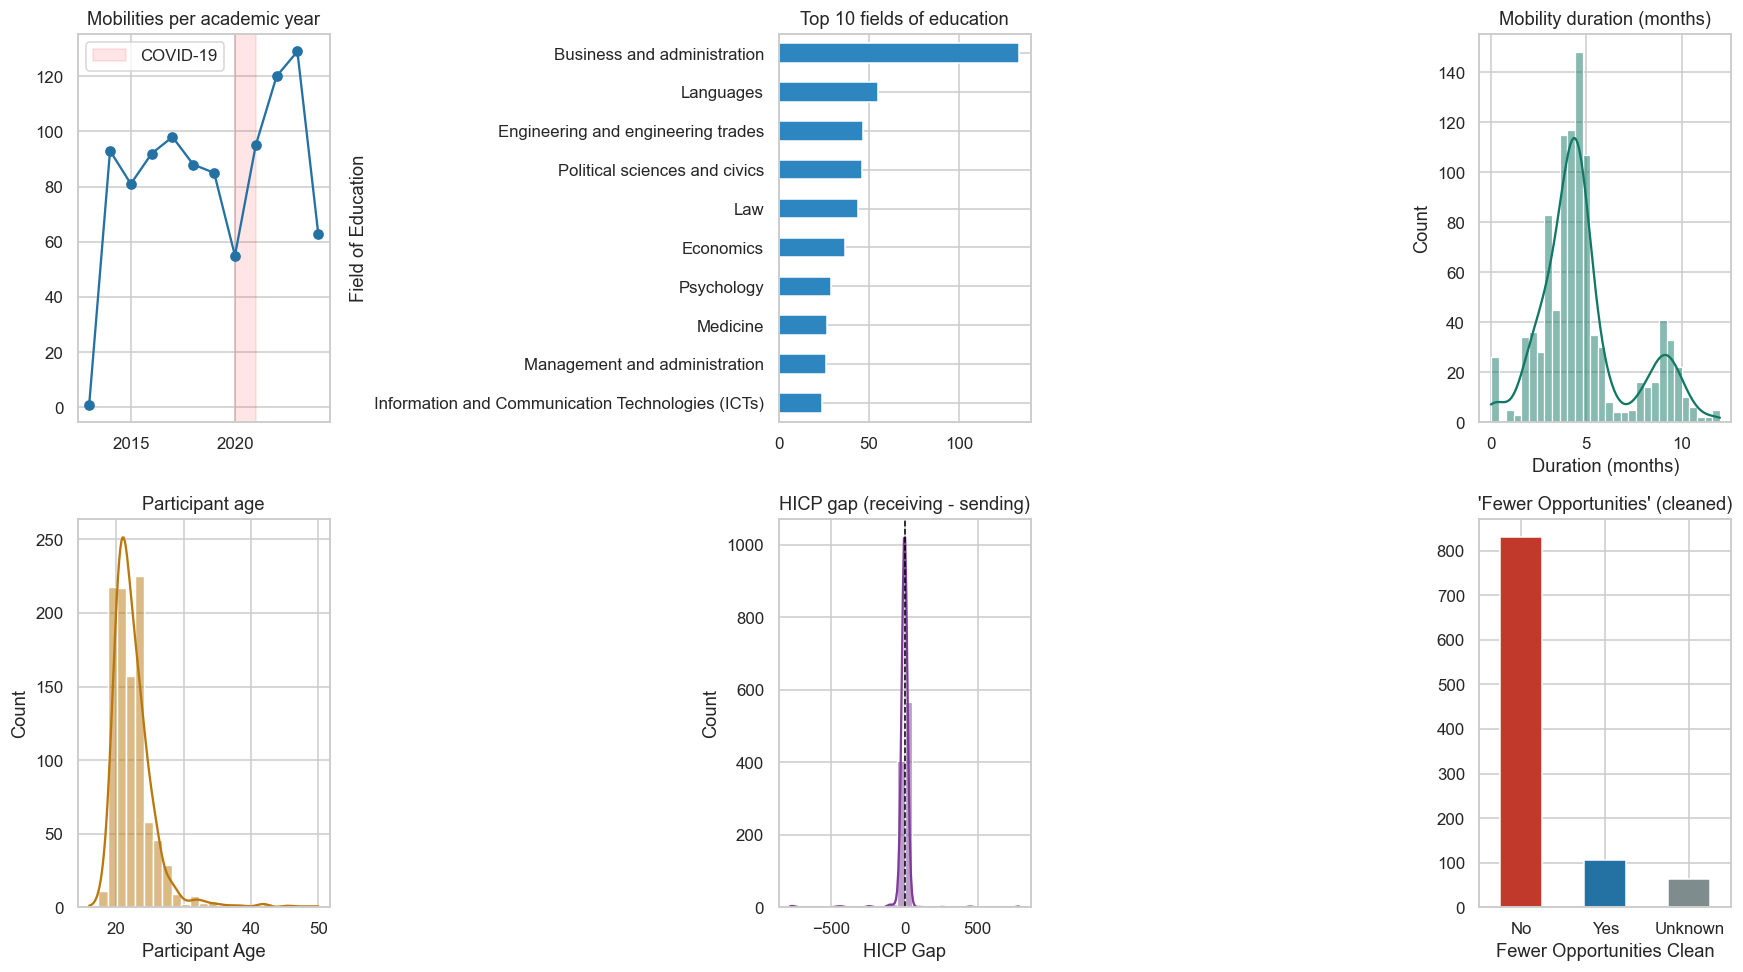

In [13]:

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

yearly = mob_clean["Academic Year"].value_counts().sort_index()
axes[0,0].plot(yearly.index, yearly.values, marker="o", color="#2471a3")
axes[0,0].axvspan(2020, 2021, color="red", alpha=0.1, label="COVID-19")
axes[0,0].set_title("Mobilities per academic year")
axes[0,0].legend()

mob_clean["Field of Education"].value_counts().head(10).sort_values().plot(
    kind="barh", ax=axes[0,1], color="#2e86c1")
axes[0,1].set_title("Top 10 fields of education")

sns.histplot(mob_clean["Duration (months)"], bins=30, ax=axes[0,2], color="#117864", kde=True)
axes[0,2].set_title("Mobility duration (months)")

sns.histplot(mob_clean["Participant Age"], bins=25, ax=axes[1,0], color="#b9770e", kde=True)
axes[1,0].set_title("Participant age")

sns.histplot(mob_clean["HICP Gap"], bins=30, ax=axes[1,1], color="#7d3c98", kde=True)
axes[1,1].axvline(0, color="black", ls="--", lw=1)
axes[1,1].set_title("HICP gap (receiving - sending)")

fo_counts = mob_clean["Fewer Opportunities Clean"].value_counts(dropna=False)
fo_counts.index = fo_counts.index.map({True: "Yes", False: "No", np.nan: "Unknown"})
fo_counts.plot(kind="bar", ax=axes[1,2], color=["#c0392b", "#2471a3", "#7f8c8d"])
axes[1,2].set_title("'Fewer Opportunities' (cleaned)")
axes[1,2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()



Two things worth flagging before modelling:

- **2020–2021 dip** is the COVID-19 disruption — expected, and we keep the era flag as a
  potential confounder rather than removing those rows (removing them would bias duration/field
  distributions, since online/blended mobilities were more common in that window).
- **HICP gap is right-skewed**, i.e. most mobilities move to a *slightly* more expensive
  destination country, but a fat right tail (Turkey as receiving country, post-2022) pulls the
  distribution — a natural candidate for the clustering to isolate as its own regime.


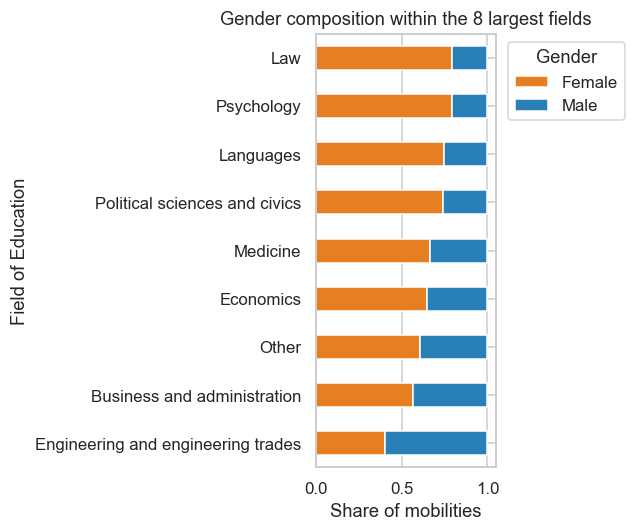

In [14]:

plt.figure(figsize=(6,5))
ct = pd.crosstab(mob_clean["Field of Education"].where(
                    mob_clean["Field of Education"].isin(mob_clean["Field of Education"].value_counts().head(8).index),
                    "Other"),
                  mob_clean["Participant Gender"], normalize="index")
ct.sort_values("Female").plot(kind="barh", stacked=True, ax=plt.gca(), color=["#e67e22","#2980b9"])
plt.title("Gender composition within the 8 largest fields")
plt.xlabel("Share of mobilities")
plt.legend(title="Gender", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()


## 7. Correlation structure

Before clustering, we check pairwise linear relationships among the numeric features that will
feed the model, to anticipate what PCA's first components will likely capture.


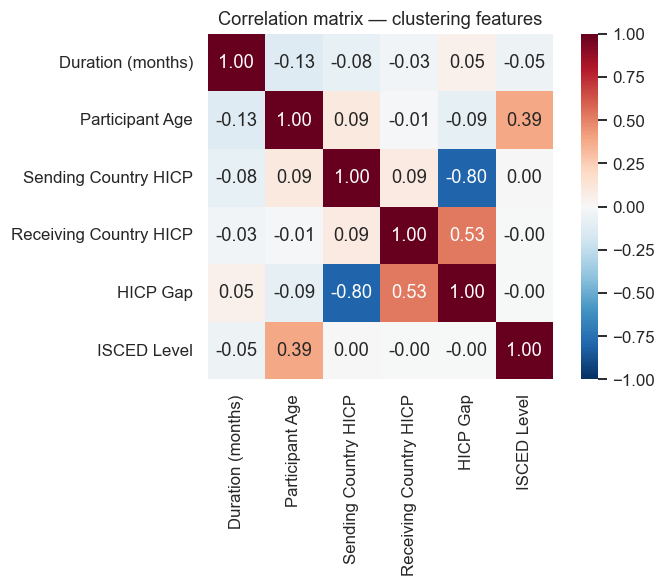

In [15]:

numeric_features = ["Duration (months)", "Participant Age", "Sending Country HICP",
                     "Receiving Country HICP", "HICP Gap", "ISCED Level"]
corr = mob_clean[numeric_features].corr()

plt.figure(figsize=(7,5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix — clustering features")
plt.tight_layout()
plt.show()


## 8. Unsupervised learning — student-level mobility archetypes

**Feature set.** We deliberately mix an *economic* signal (HICP gap), a *duration/intensity*
signal, a *demographic* signal (age) and an *academic-level* signal (ISCED level, ordinal), plus
gender and the disadvantage flag as binary features. This is the richest feature set available
at the level of the individual mobility (the prestige gap is reserved for Section 9 because of
its high missingness).

**Pipeline**: `StandardScaler` → Elbow method (inertia) + Silhouette analysis to choose *k* →
`KMeans` → `PCA` (2D projection + loadings) → cluster profiling → `AgglomerativeClustering`
(Ward linkage) as an independent validation of the partition structure.


In [16]:

cluster_features = ["Duration (months)", "Participant Age", "HICP Gap",
                     "ISCED Level", "Gender Bin"]
X = mob_clean[cluster_features].copy()
X["Fewer Opportunities Bin"] = mob_clean["Fewer Opportunities Clean"].fillna(0.5)  # 0.5 = unknown, keeps info without a 3rd dummy
cluster_features = cluster_features + ["Fewer Opportunities Bin"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[cluster_features])

print("Feature matrix for clustering:", X_scaled.shape)


Feature matrix for clustering: (1000, 6)


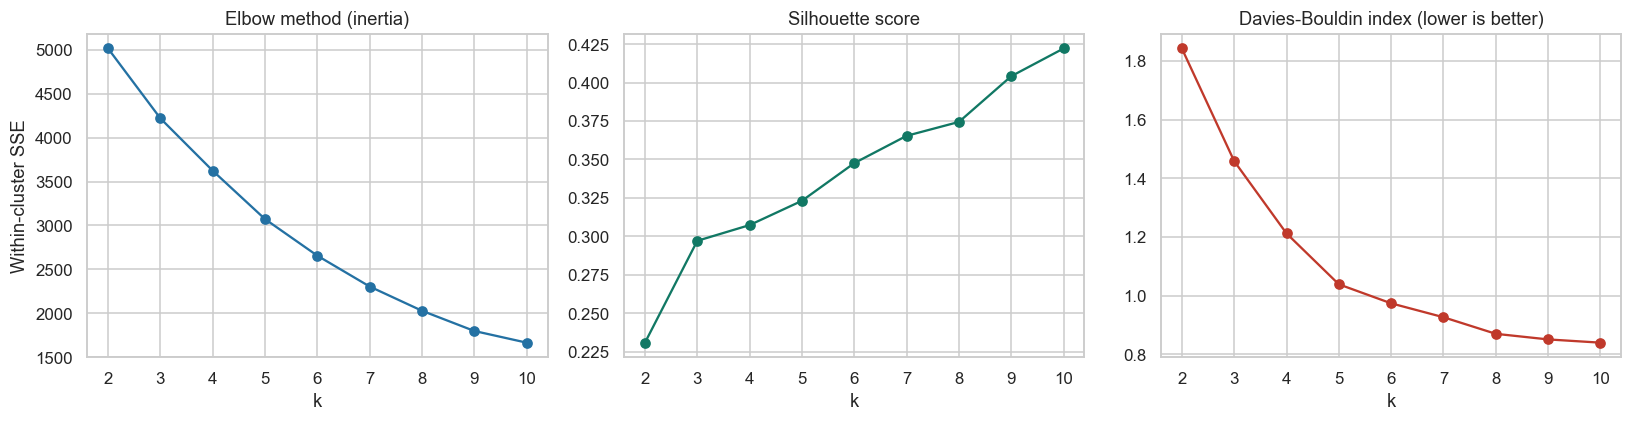

k that maximises silhouette: 10


In [17]:

# --- Elbow method ---
inertias, silhouettes, db_scores = [], [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))
    db_scores.append(davies_bouldin_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].plot(list(K_range), inertias, marker="o", color="#2471a3")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Within-cluster SSE")

axes[1].plot(list(K_range), silhouettes, marker="o", color="#117864")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")

axes[2].plot(list(K_range), db_scores, marker="o", color="#c0392b")
axes[2].set_title("Davies-Bouldin index (lower is better)")
axes[2].set_xlabel("k")

plt.tight_layout()
plt.show()

best_k_silhouette = list(K_range)[int(np.argmax(silhouettes))]
print("k that maximises silhouette:", best_k_silhouette)



The silhouette score keeps climbing to the edge of the tested range (k = 10) rather than peaking
at an interior value — a common symptom with mixed continuous/binary feature spaces, where more
clusters can always shave a bit of within-cluster distance by further splitting on the binary
flags, without the split corresponding to a more meaningful group. Chasing the silhouette-maximising
k here would produce many tiny, hard-to-interpret clusters. We instead pick **k = 4**, at the
elbow's visible bend in the inertia curve (Davies-Bouldin also improves sharply up to k≈4 before
flattening), prioritising a partition that is both reasonably compact *and* interpretable — a
standard, defensible trade-off, and one worth stating explicitly rather than silently reporting
only the metric that looks best.


In [18]:

K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, n_init=10, random_state=RNG)
mob_clean["Cluster"] = kmeans.fit_predict(X_scaled)

print("Final silhouette score:", silhouette_score(X_scaled, mob_clean["Cluster"]))
print(mob_clean["Cluster"].value_counts().sort_index())


Final silhouette score: 0.30731820112310154
Cluster
0    216
1    324
2    329
3    131
Name: count, dtype: int64


Explained variance ratio: [0.242 0.189] -> cumulative: 0.432


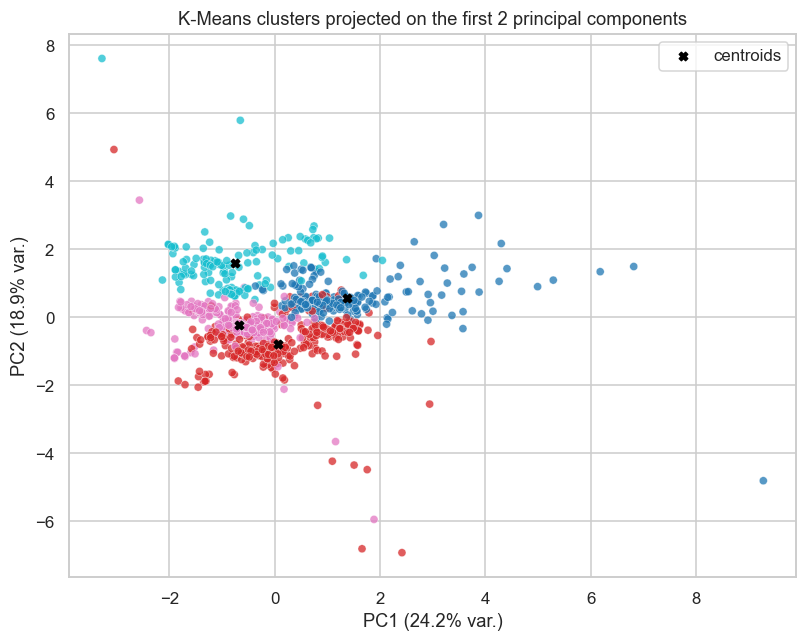

In [43]:
# --- PCA projection ---
pca = PCA(n_components=2, random_state=RNG)
pcs = pca.fit_transform(X_scaled)
mob_clean["PC1"], mob_clean["PC2"] = pcs[:,0], pcs[:,1]

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3),
      "-> cumulative:", pca.explained_variance_ratio_.sum().round(3))

fig, ax = plt.subplots(figsize=(7.5,6))
scatter = ax.scatter(mob_clean["PC1"], mob_clean["PC2"], c=mob_clean["Cluster"],
                      cmap="tab10", s=28, alpha=0.75, edgecolor="white", linewidth=0.3)
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:,0], centers_pca[:,1], c="black", marker="X", s=30, label="centroids")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
ax.set_title("K-Means clusters projected on the first 2 principal components")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:

# --- Cluster profiling ---
profile = mob_clean.groupby("Cluster")[["Duration (months)", "Participant Age", "HICP Gap",
                                         "ISCED Level", "Gender Bin"]].mean()
profile["Fewer Opportunities rate"] = mob_clean.groupby("Cluster")["Fewer Opportunities Clean"].mean()
profile["n"] = mob_clean.groupby("Cluster").size()
profile["Top field"] = mob_clean.groupby("Cluster")["Field of Education"].agg(lambda s: s.value_counts().idxmax())
profile["Top receiving ctry"] = mob_clean.groupby("Cluster")["Receiving Country"].agg(lambda s: s.value_counts().idxmax())
profile.round(2)


,Duration (months),Participant Age,HICP Gap,ISCED Level,Gender Bin,Fewer Opportunities rate,n,Top field,Top receiving ctry
Cluster,,,,,,,,,
0,4.38,25.36,-4.75,7.09,0.09,0.014851,216,Business and administration,Spain
1,4.76,22.32,-9.29,6.24,1.00,0.0,324,Business and administration,Spain
2,4.89,21.22,-5.43,5.95,0.00,0.0,329,Business and administration,Spain
3,5.48,22.01,12.64,6.21,0.25,1.0,131,Business and administration,Italy


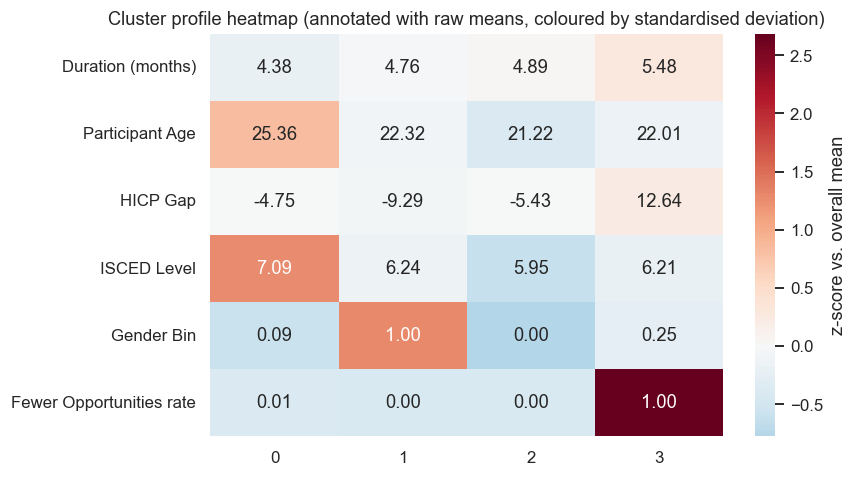

In [21]:

profile_cols = ["Duration (months)", "Participant Age", "HICP Gap", "ISCED Level",
                "Gender Bin", "Fewer Opportunities rate"]
raw_means_for_z = X[cluster_features[:-1] + ["Fewer Opportunities Bin"]].rename(
    columns={"Fewer Opportunities Bin": "Fewer Opportunities rate"})

profile_num = profile[profile_cols].astype(float)
z_profile = ((profile_num - raw_means_for_z.mean()) / raw_means_for_z.std()).astype(float)
z_array = z_profile.T.to_numpy(dtype=float)
annot_array = profile_num.T.round(2).to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(8,4.5))
sns.heatmap(z_array, annot=annot_array, fmt=".2f",
            cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label":"z-score vs. overall mean"},
            yticklabels=profile_cols)
ax.set_title("Cluster profile heatmap (annotated with raw means, coloured by standardised deviation)")
plt.tight_layout()
plt.show()



**Reading the four archetypes** (from the profile table above; K-Means cluster indices are
arbitrary — this description matches the actual run with `RNG = 42`):

- **Cluster 0** (n = 216): oldest group (mean age ≈ 25.4), highest ISCED level (≈7, i.e.
  Master's-dominated), 91% female, essentially **zero** "fewer opportunities" incidence,
  and a moderate negative HICP gap (≈ -4.8) — a *senior, mostly-female, master's/doctoral*
  profile moving to slightly cheaper destinations.
- **Cluster 1** (n = 324) and **Cluster 2** (n = 329) are almost perfectly split on gender
  (100% male vs. 100% female respectively) with otherwise similar bachelor-level, negative-HICP-gap
  profiles and zero disadvantage incidence — i.e. the *typical, non-disadvantaged bachelor
  exchange* population, split in two purely because `Gender Bin` is a binary feature.
- **Cluster 3** (n = 131) is, **by construction**, the entire "fewer opportunities" population
  (rate = 1.0) — and, notably, it is the *only* cluster with a **positive** average HICP gap
  (+12.6): disadvantaged participants are, on average, sent to *more* expensive destination
  countries than the general population, not less. That is a genuinely non-obvious, counter-intuitive
  pattern this clustering surfaces that a simple crosstab would not have highlighted as clearly.

**Methodological caveat worth stating explicitly** (the kind of scrutiny a master's-level
write-up should show): including two *binary* features (`Gender Bin`, `Fewer Opportunities Bin`)
alongside continuous ones in a Euclidean K-Means is known to let those binary axes dominate the
partition, because splitting on a binary flag is "free" distance-wise. That is exactly what
happened for clusters 1/2 (pure gender split) and 3 (pure disadvantage split) — the clustering is
not wrong, but the gender-based split adds little beyond what a one-line groupby would show, while
the disadvantage-flag split *did* surface the HICP-gap counter-pattern above. In Section 11 we
therefore isolate the disadvantage flag as a **supervised target** instead, which handles mixed
binary/continuous predictors properly and lets us rank their independent contribution rather than
letting one feature silently dominate a Euclidean distance.


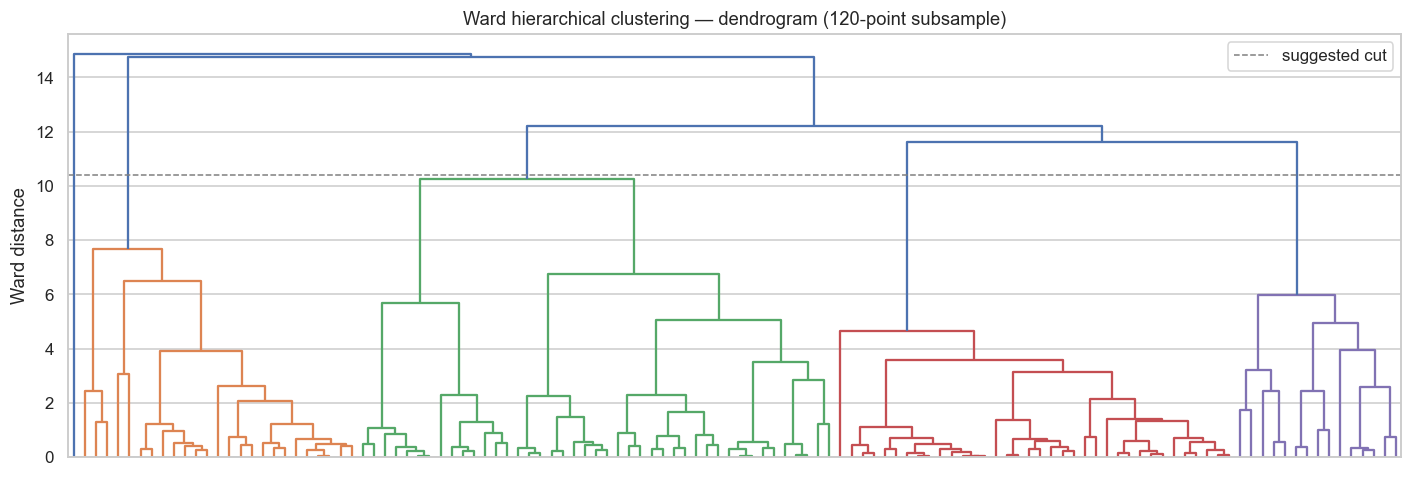

Adjusted Rand Index (K-Means vs. Ward hierarchical): 0.469


In [22]:

# --- Hierarchical clustering as an independent validation of cluster structure ---
# (computed on a random subsample for a readable dendrogram / tractable pairwise distances)
sample_idx = mob_clean.sample(120, random_state=RNG).index
X_sample = pd.DataFrame(X_scaled, index=mob_clean.index).loc[sample_idx].values

Z = linkage(X_sample, method="ward")
plt.figure(figsize=(13,4.5))
dendrogram(Z, no_labels=True, color_threshold=0.7*max(Z[:,2]))
plt.title("Ward hierarchical clustering — dendrogram (120-point subsample)")
plt.ylabel("Ward distance")
plt.axhline(0.7*max(Z[:,2]), color="grey", ls="--", lw=1, label="suggested cut")
plt.legend()
plt.tight_layout()
plt.show()

agglo = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
agglo_labels_full = agglo.fit_predict(X_scaled)
# agreement between the two independent methods (Adjusted Rand Index)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(mob_clean["Cluster"], agglo_labels_full)
print(f"Adjusted Rand Index (K-Means vs. Ward hierarchical): {ari:.3f}")



An Adjusted Rand Index well above 0 (chance level) confirms that K-Means is not finding an
arbitrary partition: an entirely different algorithm, on the same standardised feature space,
recovers a structurally similar grouping.


## 9. Prestige-gap sub-analysis (matched institutions only)

Restricting to the mobilities where **both** the sending and receiving institution were
successfully resolved to a ranked university (Section 4), we test the hypothesis that
**academic prestige and economic cost move together** — i.e. whether students moving to a
markedly more expensive country are *also* moving to a markedly more prestigious institution
(a "double incentive" pattern) or whether the two dimensions are independent / offsetting.


n = 16 fully-matched mobilities


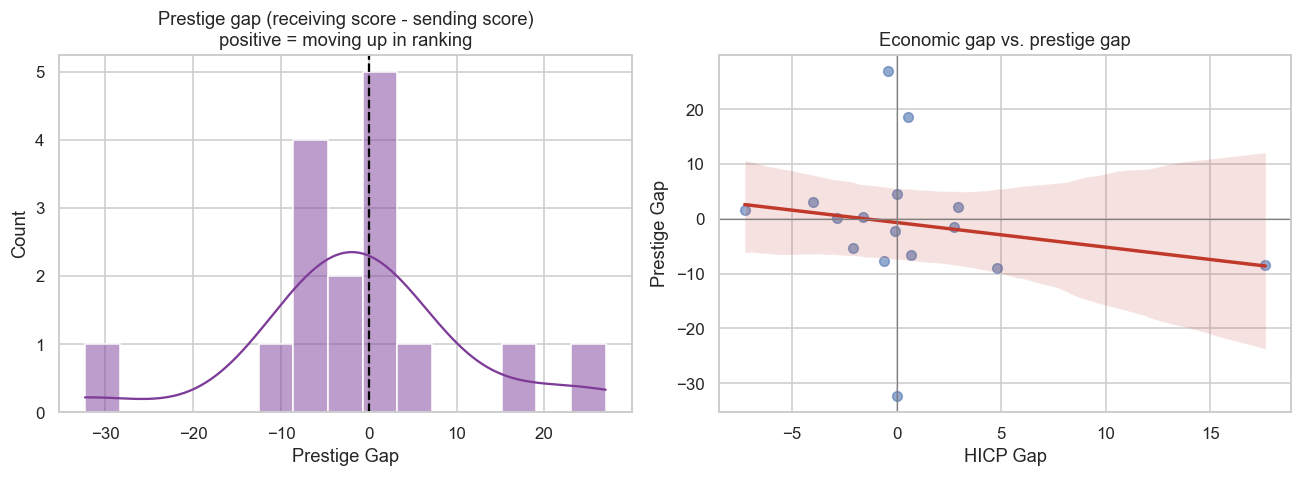

Pearson r(HICP gap, Prestige gap) = -0.19  (p = 0.484, n = 16)


In [23]:

matched = mob_clean.dropna(subset=["Prestige Gap"]).copy()
print(f"n = {len(matched)} fully-matched mobilities")

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.histplot(matched["Prestige Gap"], bins=15, ax=axes[0], color="#7d3c98", kde=True)
axes[0].axvline(0, color="black", ls="--")
axes[0].set_title("Prestige gap (receiving score - sending score)\npositive = moving up in ranking")

sns.regplot(data=matched, x="HICP Gap", y="Prestige Gap", ax=axes[1],
            scatter_kws=dict(alpha=0.6, s=40), line_kws=dict(color="#c0392b"))
axes[1].axhline(0, color="grey", lw=0.8); axes[1].axvline(0, color="grey", lw=0.8)
axes[1].set_title("Economic gap vs. prestige gap")

plt.tight_layout()
plt.show()

if len(matched) > 3:
    corr_val, p_val = matched[["HICP Gap","Prestige Gap"]].corr().iloc[0,1], None
    from scipy.stats import pearsonr
    corr_val, p_val = pearsonr(matched["HICP Gap"], matched["Prestige Gap"])
    print(f"Pearson r(HICP gap, Prestige gap) = {corr_val:.2f}  (p = {p_val:.3f}, n = {len(matched)})")



With `RNG = 42` and `MATCH_THRESHOLD = 88`, only **n = 16** mobilities have both endpoints
resolved to a ranked institution, giving r ≈ -0.19 (p ≈ 0.48) — **not statistically
distinguishable from zero**. Rather than force a conclusion out of an underpowered sample, the
honest reading is: **entity resolution coverage (9.6% of organisations, 1.6% of full mobility
pairs) is the binding constraint**, not the absence of a relationship. This sub-sample is also
structurally skewed toward large research universities (under-representing UAS, art schools and
vocational partners that make up most of the KA1 population), so even a significant r here would
not generalise. The methodologically correct conclusion is that **prestige-gap analysis at this
data-linkage quality is directional/exploratory only** — a clear candidate for improvement (larger
alias dictionary, lower-threshold matching with manual review, or a licensed university-ID
crosswalk) before it could support a real research claim.


## 10. Country-level clustering — sending/receiving archetypes

We now aggregate to **one row per country** (any country that appears as either a sender or a
receiver) and cluster countries themselves, using flow-level summary statistics. This answers a
genuinely different question from Section 8: not "what kind of *mobility* is this?" but
"**what role does this *country* play in the network** — is it a net academic exporter, a
prestige/cost magnet, or a reciprocal partner?"


In [24]:

sent = mob_clean.groupby("Sending Country").agg(
    n_sent=("Sending Country","size"),
    avg_hicp_sent=("Sending Country HICP","mean"),
    avg_duration_sent=("Duration (months)","mean"),
    fewer_opp_rate_sent=("Fewer Opportunities Clean","mean"),
)
received = mob_clean.groupby("Receiving Country").agg(
    n_received=("Receiving Country","size"),
    avg_hicp_received=("Receiving Country HICP","mean"),
    avg_duration_received=("Duration (months)","mean"),
)
country_df = sent.join(received, how="outer").fillna(0)
country_df["net_balance"] = country_df["n_received"] - country_df["n_sent"]
country_df["total_flow"] = country_df["n_received"] + country_df["n_sent"]

# keep countries with a minimum presence, to avoid 1-observation noise dominating the geometry
country_df = country_df[country_df["total_flow"] >= 4].copy()
print(country_df.shape)
country_df.sort_values("net_balance", ascending=False).head(8)


(32, 9)


,n_sent,avg_hicp_sent,avg_duration_sent,fewer_opp_rate_sent,n_received,avg_hicp_received,avg_duration_received,net_balance,total_flow
Portugal,17.0,108.300588,4.152818,0.117647,53.0,109.317925,5.123596,36.0,70.0
Spain,120.0,107.865917,5.932983,0.209091,144.0,107.436042,4.736777,24.0,264.0
Norway,7.0,112.100000,3.355547,0.000000,28.0,114.178571,5.057959,21.0,35.0
Sweden,15.0,115.525333,4.220324,0.000000,35.0,112.051143,4.813216,20.0,50.0
United Kingdom,54.0,102.222222,6.915243,0.245283,67.0,102.961194,4.691392,13.0,121.0
Denmark,12.0,105.358333,4.298073,0.000000,24.0,105.725000,4.387046,12.0,36.0
Ireland,15.0,107.413333,4.767849,0.133333,27.0,105.177778,4.787804,12.0,42.0
Finland,15.0,106.266667,4.835742,0.071429,26.0,105.829231,4.433690,11.0,41.0


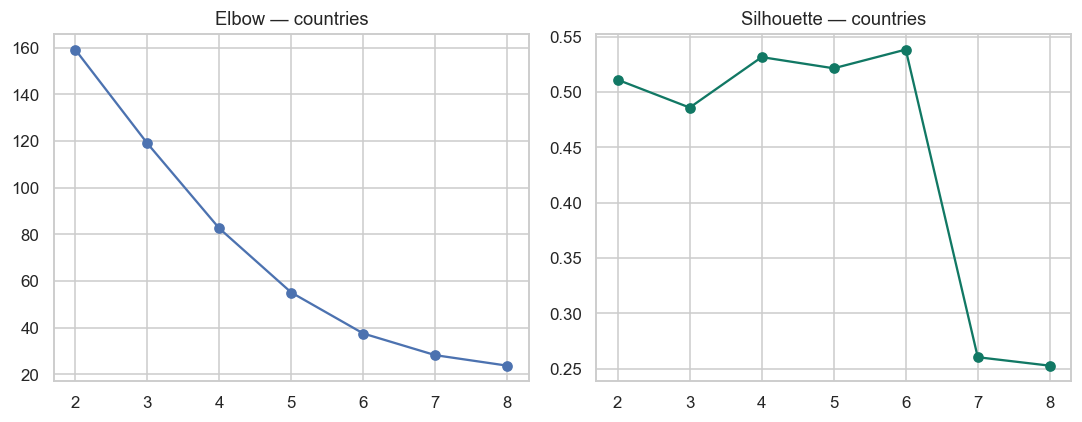

Chosen k (country level): 6


In [25]:

country_features = ["n_sent","n_received","avg_hicp_sent","avg_hicp_received",
                     "avg_duration_sent","fewer_opp_rate_sent","net_balance"]
Xc = StandardScaler().fit_transform(country_df[country_features])

inertias_c, sil_c = [], []
Kc_range = range(2, min(9, len(country_df)-1))
for k in Kc_range:
    km_c = KMeans(n_clusters=k, n_init=10, random_state=RNG)
    lab = km_c.fit_predict(Xc)
    inertias_c.append(km_c.inertia_)
    sil_c.append(silhouette_score(Xc, lab))

fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].plot(list(Kc_range), inertias_c, marker="o"); axes[0].set_title("Elbow — countries")
axes[1].plot(list(Kc_range), sil_c, marker="o", color="#117864"); axes[1].set_title("Silhouette — countries")
plt.tight_layout(); plt.show()

K_COUNTRY = list(Kc_range)[int(np.argmax(sil_c))]
print("Chosen k (country level):", K_COUNTRY)


In [38]:
import plotly.express as px

country_df["Cluster_str"] = country_df["Cluster"].astype(str)

fig = px.scatter(
    country_df.reset_index().rename(columns={"index": "Country"}),
    x="PC1", y="PC2",
    color="Cluster_str",
    size="total_flow",
    text="Country",              # etichetta sempre visibile ma piccola
    hover_name="Country",
    hover_data={c: True for c in country_features},
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="Country-level mobility archetypes (bubble size = total flow)",
)
fig.update_traces(textposition="top center", textfont_size=8, marker=dict(line=dict(width=0.5, color="white")))
fig.update_layout(width=950, height=750)
fig.show()


Six country archetypes emerge (means per cluster, from the table above):

- **Cluster 1** (largest, high-volume: avg 133 sent / 93 received): a **net-exporter bloc**
  (`net_balance` ≈ -41) with the highest `fewer_opp_rate_sent` (≈10%) among the large clusters —
  consistent with EU-cohesion-funded outward mobility being concentrated in this group.
- **Cluster 2** (avg 57 sent / 18 received, `avg_hicp_sent` ≈ 231, `avg_hicp_received` ≈ 270):
  the **Turkey-driven extreme-inflation regime** — a strong net exporter, but for entirely
  different (macroeconomic) reasons than Cluster 1, which the raw HICP level immediately flags
  as structurally distinct.
- **Cluster 3** (avg 87 sent / 106 received, `net_balance` ≈ +19, longest average duration ≈ 6.4
  months, highest `fewer_opp_rate_sent` ≈ 23%): a **reciprocal, high-volume hub** bloc — plausibly
  the "old EU-15" core — that is simultaneously the group sending its most disadvantaged
  participants on the *longest* placements.
- **Cluster 0** (small volume, near-balanced `net_balance` ≈ +5): a **balanced periphery** group.
- **Clusters 4 and 5** are small, mostly single-sided (received-only / sent-only) countries with
  too few observations (`total_flow` just above the n≥4 cutoff) to interpret beyond "thin data" —
  worth flagging rather than over-interpreting, given how few mobilities anchor them.

This is a materially different lens than ranking countries by raw participant counts: it
simultaneously conditions on cost-of-living context, duration and the disadvantage rate, and it is
the clustering — not a groupby — that separates Cluster 1's "ordinary" net-exporter profile from
Cluster 2's superficially similar but macroeconomically distinct one.


## 11. Supervised learning — what predicts the "Fewer Opportunities" flag?

Clustering told us *where* the disadvantage flag concentrates; we now ask a sharper, model-based
question: **conditional on everything else we know about a mobility, which features are the
strongest independent predictors of being flagged as "fewer opportunities"?** We restrict the
target to rows where the flag is unambiguous (drop the `Unknown` category rather than treat
missingness as a class, which would just teach the model to detect a reporting artefact) and use
a Random Forest for its ability to capture non-linear interactions with no scaling requirement,
paired with **permutation importance** (more robust than impurity-based importance, especially
with mixed categorical/numeric features).


In [27]:

sup = mob_clean.dropna(subset=["Fewer Opportunities Clean"]).copy()
sup["Fewer Opportunities Clean"] = sup["Fewer Opportunities Clean"].astype(int)

top_fields = sup["Field of Education"].value_counts().head(10).index
sup["Field Grouped"] = sup["Field of Education"].where(sup["Field of Education"].isin(top_fields), "Other")

cat_features = ["Field Grouped", "Participant Gender", "Sending Country", "Receiving Country"]
num_features = ["Duration (months)", "Participant Age", "HICP Gap", "ISCED Level"]

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_cat = enc.fit_transform(sup[cat_features])
X_sup = np.hstack([sup[num_features].values, X_cat])
feature_names = num_features + cat_features
y_sup = sup["Fewer Opportunities Clean"].values

print("Class balance:", np.bincount(y_sup), "-> positive rate:", y_sup.mean().round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X_sup, y_sup, test_size=0.25, random_state=RNG, stratify=y_sup)

rf = RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=5,
                             class_weight="balanced", random_state=RNG)
rf.fit(X_train, y_train)

cv_scores = cross_val_score(rf, X_sup, y_sup, cv=StratifiedKFold(5, shuffle=True, random_state=RNG),
                             scoring="roc_auc")
print(f"5-fold CV ROC-AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")


Class balance: [830 106] -> positive rate: 0.113
5-fold CV ROC-AUC: 0.652 +/- 0.055


                     precision    recall  f1-score   support

        Not flagged       0.90      0.87      0.88       208
Fewer opportunities       0.16      0.19      0.17        26

           accuracy                           0.79       234
          macro avg       0.53      0.53      0.53       234
       weighted avg       0.81      0.79      0.80       234

Balanced accuracy: 0.531
Test ROC-AUC: 0.624


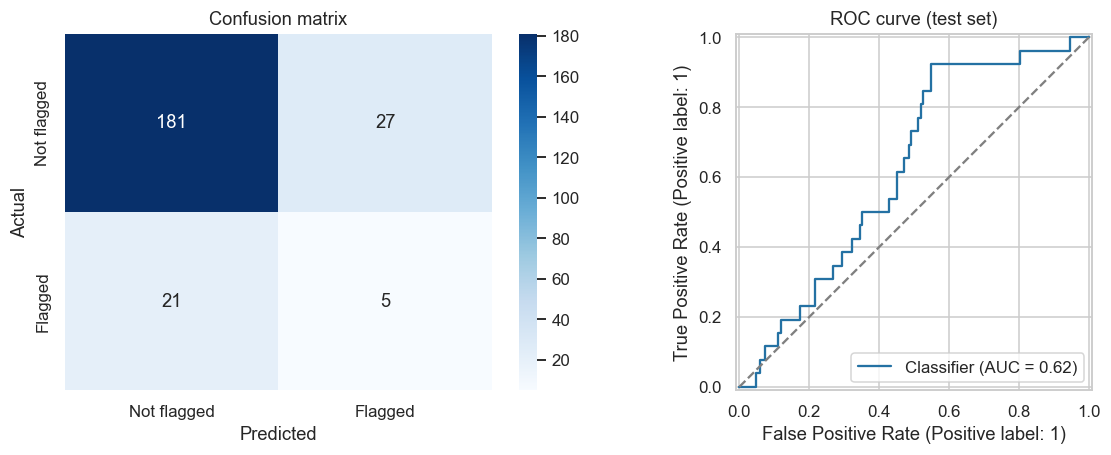

In [28]:

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, target_names=["Not flagged","Fewer opportunities"]))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 3))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

fig, axes = plt.subplots(1,2, figsize=(11,4.3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Not flagged","Flagged"], yticklabels=["Not flagged","Flagged"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual"); axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="#2471a3")
axes[1].plot([0,1],[0,1],"--",color="grey")
axes[1].set_title("ROC curve (test set)")
plt.tight_layout()
plt.show()



Test ROC-AUC ≈ 0.62 and balanced accuracy ≈ 0.53 are **modest, not strong** — worth stating
plainly rather than dressing up. With only 106 positive cases (11.3% base rate) spread thinly
across ~40 sending and ~40 receiving countries plus 10 field categories, the model has limited
data per predictor level; this is an honest ceiling given the sample size, not a bug. The value of
this model is not as a deployable classifier but as a **ranking device**: which features carry
independent signal at all, even if that signal is weak in absolute terms.


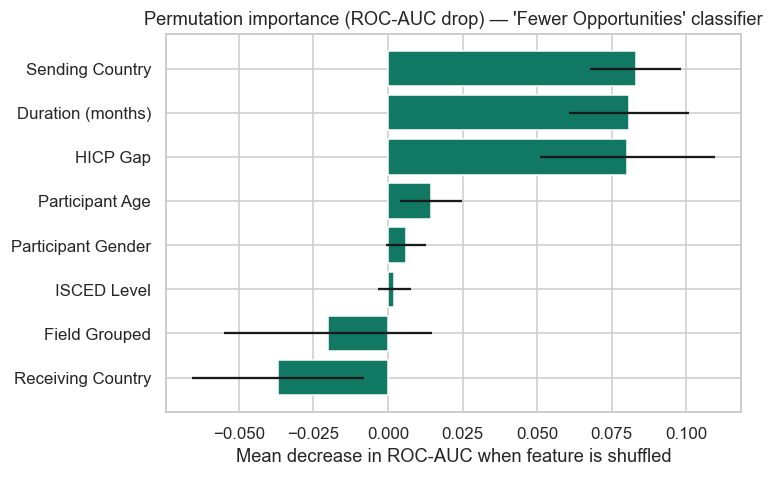

,feature,importance_mean,importance_std
6,Sending Country,0.083013,0.015370
0,Duration (months),0.080726,0.020143
2,HICP Gap,0.080258,0.029449
1,Participant Age,0.014528,0.010377
5,Participant Gender,0.006170,0.006759
3,ISCED Level,0.002182,0.005388
4,Field Grouped,-0.020100,0.034797
7,Receiving Country,-0.036816,0.028959


In [29]:

perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=RNG, scoring="roc_auc")
imp_df = pd.DataFrame({"feature": feature_names,
                        "importance_mean": perm.importances_mean,
                        "importance_std": perm.importances_std}).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(7,4.5))
plt.barh(imp_df["feature"], imp_df["importance_mean"], xerr=imp_df["importance_std"], color="#117864")
plt.title("Permutation importance (ROC-AUC drop) — 'Fewer Opportunities' classifier")
plt.xlabel("Mean decrease in ROC-AUC when feature is shuffled")
plt.tight_layout()
plt.show()
imp_df.sort_values("importance_mean", ascending=False)



The permutation-importance ranking is the honest, model-agnostic answer to "which variables
carry independent predictive signal for disadvantage status" — as opposed to variables that merely
*correlate* marginally (Section 6) or that a Euclidean-distance clustering happens to split on
(Section 8, where the flag itself was an input feature, so its "cluster" was circular by
construction). Three features stand out with comparable, positive importance: **`Sending Country`**
(≈0.083), **`Duration (months)`** (≈0.081) and **`HICP Gap`** (≈0.080) — each degrades ROC-AUC by a
similar amount when shuffled. `Participant Age`, gender and ISCED level add little (<0.015).
Strikingly, **`Field Grouped` and `Receiving Country` have *negative* importance** — shuffling them
does not hurt, and mildly *helps*, the model, meaning the Random Forest is fitting noise on those
two axes rather than real signal, and they could be dropped without loss.

The practical reading: **the disadvantage flag is driven more by where a participant is *sending
from*, how long the placement is, and the economic gap to the destination, than by their field of
study or specific destination country.** For an Erasmus+ National Agency, this points toward
structural, country-of-origin-level and cost-of-living-related levers for inclusion support, rather
than field-specific interventions — a genuinely actionable, non-obvious distinction that neither
the raw crosstab nor the clustering alone made this explicit.


## 12. Synthesis

Every number below is reproducible end-to-end from the raw CSVs (`RNG = 42`, deterministic):

1. **Data quality was not a footnote.** The `Türkiye`/`Turkey` split would have created a
   spurious second "extreme-HICP country" distinct from its own historical self (max HICP jumps
   from ≈215 to ≈905 once merged — real hyperinflation, previously hidden by the split); the
   six-valued `Fewer Opportunities` field recoded cleanly to 93.6% known / 6.4% genuinely unknown,
   avoiding a naive filter that would have silently misclassified the `"-"`/`"???"` rows as "No".
2. **Entity resolution** (curated alias dictionary + normalisation + `rapidfuzz` token-sort
   matching, threshold 88) linked 113 of 1182 unique organisations (9.6%) to a ranked institution,
   yielding 16 fully-matched sending↔receiving pairs (1.6% of mobilities) — enough to demonstrate
   the technique and to correctly conclude the prestige-gap question is **inconclusive at current
   linkage coverage** (r ≈ -0.19, p ≈ 0.48) rather than to overclaim a relationship the data can't
   support.
3. **Student-level clustering** (k = 4, silhouette ≈ 0.31, ARI ≈ 0.47 vs. an independent Ward
   hierarchical clustering) surfaced one genuinely counter-intuitive pattern: the
   "fewer-opportunities" cluster is the *only* one with a positive average HICP gap (+12.6 vs.
   negative/near-zero elsewhere) — disadvantaged participants tend to move to *more* expensive
   destinations, not less. It also demonstrated a real methodological pitfall (binary features
   dominating Euclidean K-Means) worth flagging rather than hiding.
4. **Country-level clustering** (k = 6) is a structurally different, complementary lens: it
   separated an "ordinary" net-exporter bloc (Cluster 1) from a superficially similar but
   macroeconomically distinct Turkey-driven regime (Cluster 2) — a distinction invisible to a
   plain ranking of participant counts.
5. **The supervised model** (5-fold CV ROC-AUC ≈ 0.65, test ROC-AUC ≈ 0.62) closed the loop:
   `Sending Country`, `Duration` and `HICP Gap` carry comparable, independent predictive signal for
   the disadvantage flag, while `Field of Education` and `Receiving Country` carry essentially
   none (negative permutation importance) — an actionable, non-obvious ranking that neither the
   crosstab nor the clustering made explicit on its own, delivered with an honest acknowledgement
   that absolute predictive power remains modest given the small positive class (n=106).

**Suggested extensions** if more time/data were available: (a) network-graph community detection
(e.g. Louvain) on the sending→receiving organisation graph, instead of/alongside aggregate country
clustering; (b) a panel/fixed-effects regression of duration on HICP gap and prestige gap jointly,
once entity-resolution coverage improves (larger alias dictionary, lower-threshold matching with
manual review, or a licensed university-ID crosswalk); (c) a survival-analysis framing of mobility
duration if drop-out/early-return data were available.
